In [4]:
import os
import re
import pandas as pd

ROOT_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/Dataset_3x50_Final"

LABEL_MAP = {
    "Normal": 0,
    "DME": 1,
    "AMD": 2
}

VALID_EXTS = (".tif", ".tiff", ".png", ".jpg", ".jpeg")

def extract_patient_id(folder_name):
    name = folder_name.strip()
    prefix = name.split("(")[0].strip().upper()
    nums = re.findall(r"\d+", name)
    if len(nums) == 0:
        raise ValueError(f"No numeric ID found in folder name: {folder_name}")
    return f"{prefix}_{nums[0]}"

rows = []

for label_text, class_id in LABEL_MAP.items():
    class_dir = os.path.join(ROOT_DIR, label_text)
    if not os.path.isdir(class_dir):
        raise RuntimeError(f"Missing class directory: {class_dir}")

    for volume_folder in sorted(os.listdir(class_dir)):
        volume_dir = os.path.join(class_dir, volume_folder)
        if not os.path.isdir(volume_dir):
            continue

        patient_id = extract_patient_id(volume_folder)

        image_files = [
            f for f in os.listdir(volume_dir)
            if f.lower().endswith(VALID_EXTS)
        ]

        if len(image_files) == 0:
            print(f"[WARNING] Truly empty volume skipped: {volume_dir}")
            continue

        for fname in sorted(image_files):
            rows.append({
                "label_text": label_text,
                "patient_id": patient_id,
                "new_file_path": os.path.join(volume_dir, fname),
                "three_class_label": class_id
            })

neh_df = pd.DataFrame(rows)

# -----------------------
# Final sanity checks
# -----------------------
print("\nTotal B-scans:", len(neh_df))
print("\nVolumes per class:")
print(neh_df.groupby("label_text")["patient_id"].nunique())

print("\nB-scans per volume stats:")
print(neh_df.groupby("patient_id").size().describe())



Total B-scans: 4326

Volumes per class:
label_text
AMD       48
DME       50
Normal    50
Name: patient_id, dtype: int64

B-scans per volume stats:
count    148.000000
mean      29.229730
std       15.432581
min       17.000000
25%       18.000000
50%       21.000000
75%       30.250000
max       73.000000
dtype: float64


In [5]:
# Add binary label: NORMAL=0, others=1
def add_binary_label(df):
    df["binary_label"] = (df["label_text"] != "Normal").astype(int)
    return df

neh_df = add_binary_label(neh_df)

In [6]:
neh_df.groupby("label_text")["patient_id"].nunique()


label_text
AMD       48
DME       50
Normal    50
Name: patient_id, dtype: int64

In [7]:
neh_df['patient_id']

0       NORMAL_1
1       NORMAL_1
2       NORMAL_1
3       NORMAL_1
4       NORMAL_1
          ...   
4321       AMD_9
4322       AMD_9
4323       AMD_9
4324       AMD_9
4325       AMD_9
Name: patient_id, Length: 4326, dtype: object

In [8]:
neh_df['new_file_path'][0]

'/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/Dataset_3x50_Final/Normal/NORMAL (1)/Image (1).TIFF'

In [1]:
import pandas as pd

df1 = pd.read_csv("/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/neh_train.csv")
df2 = pd.read_csv("/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/neh_val.csv")
df3 = pd.read_csv("/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD_2/neh_test.csv")

In [3]:
print(df1['binary_label'].value_counts())
print(df2['binary_label'].value_counts())
print(df3['binary_label'].value_counts())


binary_label
1    1568
0     977
Name: count, dtype: int64
binary_label
1    490
0    314
Name: count, dtype: int64
binary_label
1    683
0    294
Name: count, dtype: int64


In [9]:
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)

# 1. Subsample volumes to create a 50/50 balance
# Get unique patient IDs for each category
amd_patients = neh_df[neh_df['label_text'] == 'AMD']['patient_id'].unique()
dme_patients = neh_df[neh_df['label_text'] == 'DME']['patient_id'].unique()
normal_patients = neh_df[neh_df['label_text'] == 'Normal']['patient_id'].unique()

# Randomly select 25 from AMD and 25 from DME
selected_amd = np.random.choice(amd_patients, 25, replace=False)
selected_dme = np.random.choice(dme_patients, 25, replace=False)
# Keep all 50 Normal
selected_normal = normal_patients 

# Combine all selected IDs
balanced_ids = np.concatenate([selected_amd, selected_dme, selected_normal])

# Filter the original dataframe to only include these 100 volumes
balanced_neh_df = neh_df[neh_df['patient_id'].isin(balanced_ids)].copy()

balanced_neh_df.groupby("label_text")["patient_id"].nunique()
# 2. Perform the split using your logic
# train_ids, val_ids, test_ids = [], [], []

# for label in balanced_neh_df["label_text"].unique():
#     patients = balanced_neh_df.loc[
#         balanced_neh_df.label_text == label, "patient_id"
#     ].unique()

#     np.random.shuffle(patients)

#     n = len(patients)
#     n_train = int(0.6 * n)
#     n_val = int(0.2 * n)

#     train_ids.extend(patients[:n_train])
#     val_ids.extend(patients[n_train:n_train + n_val])
#     test_ids.extend(patients[n_train + n_val:])

# # Create dataframes
# train_df = balanced_neh_df[balanced_neh_df.patient_id.isin(train_ids)].reset_index(drop=True)
# val_df   = balanced_neh_df[balanced_neh_df.patient_id.isin(val_ids)].reset_index(drop=True)
# test_df  = balanced_neh_df[balanced_neh_df.patient_id.isin(test_ids)].reset_index(drop=True)

# # 3. Map labels to Binary for training
# for df in [train_df, val_df, test_df]:
#     df['binary_label'] = df['label_text'].map({'Normal': 0, 'AMD': 1, 'DME': 1})

# # Verification
# print("Final Balanced Splits (Rows/Slices):")
# print(f"Train Binary Counts:\n{train_df['binary_label'].value_counts()}")
# print(f"Val Binary Counts:\n{val_df['binary_label'].value_counts()}")
# print(f"Test Binary Counts:\n{test_df['binary_label'].value_counts()}")

label_text
AMD       25
DME       25
Normal    50
Name: patient_id, dtype: int64

In [11]:
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)

# Safety check
assert "patient_id" in balanced_neh_df.columns
assert "label_text" in balanced_neh_df.columns

train_ids = []
val_ids = []

# Split independently per class (Stratified by Patient ID)
for label in balanced_neh_df["label_text"].unique():
    patients = balanced_neh_df.loc[
        balanced_neh_df.label_text == label, "patient_id"
    ].unique()

    patients = np.array(patients)
    np.random.shuffle(patients)

    # 80% for training, remaining 20% for validation
    n = len(patients)
    n_train = int(0.8 * n)

    train_ids.extend(patients[:n_train])
    val_ids.extend(patients[n_train:])

# Create dataframes
train_df = balanced_neh_df[balanced_neh_df.patient_id.isin(train_ids)].reset_index(drop=True)
val_df   = balanced_neh_df[balanced_neh_df.patient_id.isin(val_ids)].reset_index(drop=True)

# Verification
print("--- Training Set Counts ---")
print(train_df['binary_label'].value_counts())
print("\n--- Validation Set Counts ---")
print(val_df['binary_label'].value_counts())

print(f"\nTotal Patients: {len(train_ids) + len(val_ids)}")
print(f"Train Ratio: {len(train_ids) / (len(train_ids) + len(val_ids)):.2f}")

--- Training Set Counts ---
binary_label
0    1291
1    1219
Name: count, dtype: int64

--- Validation Set Counts ---
binary_label
0    294
1    203
Name: count, dtype: int64

Total Patients: 100
Train Ratio: 0.80


In [12]:
# 1. Check for overlapping patients between sets
train_pats = set(train_df['patient_id'])
val_pats = set(val_df['patient_id'])
overlap = train_pats.intersection(val_pats)

print(f"Number of overlapping patients: {len(overlap)}")
if len(overlap) > 0:
    print(f"Warning! The following patients are in both sets: {overlap}")
else:
    print("Success: No patient overlap between Train and Val sets.")

# 2. Count unique patients per label in each dataframe
def count_unique_patients(df, name):
    counts = df.groupby('label_text')['patient_id'].nunique().reset_index()
    counts.columns = ['Label', f'Unique_Patients_{name}']
    return counts

train_counts = count_unique_patients(train_df, "Train")
val_counts = count_unique_patients(val_df, "Val")

# Merge for a clean comparison table
summary_df = pd.merge(train_counts, val_counts, on='Label')
print("\n--- Unique Patient Counts per Label ---")
print(summary_df)

# 3. Double check the total row counts (records) just in case
print("\n--- Total Record Counts (Rows) ---")
print(f"Train Rows: {len(train_df)}")
print(f"Val Rows:   {len(val_df)}")

Number of overlapping patients: 0
Success: No patient overlap between Train and Val sets.

--- Unique Patient Counts per Label ---
    Label  Unique_Patients_Train  Unique_Patients_Val
0     AMD                     20                    5
1     DME                     20                    5
2  Normal                     40                   10

--- Total Record Counts (Rows) ---
Train Rows: 2510
Val Rows:   497


In [ ]:
# train_df.to_csv("neh_reduced_split_train_80.csv", index=False)
# val_df.to_csv("neh_reduced_split_val_20.csv", index=False)

In [ ]:
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)

# Safety check
assert "patient_id" in balanced_neh_df.columns
assert "label_text" in balanced_neh_df.columns

train_ids = []
val_ids = []
test_ids = []

# Split independently per class (recommended)

for label in balanced_neh_df["label_text"].unique():
    patients = balanced_neh_df.loc[
        balanced_neh_df.label_text == label, "patient_id"
    ].unique()

    patients = np.array(patients)
    np.random.shuffle(patients)

    n = len(patients)
    n_train = int(0.6 * n)
    n_val = int(0.2 * n)

    train_ids.extend(patients[:n_train])
    val_ids.extend(patients[n_train:n_train + n_val])
    test_ids.extend(patients[n_train + n_val:])

# Create dataframes
train_df = balanced_neh_df[balanced_neh_df.patient_id.isin(train_ids)].reset_index(drop=True)
val_df   = balanced_neh_df[balanced_neh_df.patient_id.isin(val_ids)].reset_index(drop=True)
test_df  = balanced_neh_df[balanced_neh_df.patient_id.isin(test_ids)].reset_index(drop=True)

print(train_df['label_text'].value_counts())
print(val_df['label_text'].value_counts())
print(test_df['label_text'].value_counts())

label_text
Normal    977
AMD       949
DME       619
Name: count, dtype: int64
label_text
Normal    314
AMD       301
DME       189
Name: count, dtype: int64
label_text
AMD       387
DME       296
Normal    294
Name: count, dtype: int64


In [16]:
train_pat = set(train_df.patient_id.unique())
val_pat   = set(val_df.patient_id.unique())
test_pat  = set(test_df.patient_id.unique())

print("Train ∩ Val :", train_pat & val_pat)
print("Train ∩ Test:", train_pat & test_pat)
print("Val ∩ Test  :", val_pat & test_pat)


Train ∩ Val : set()
Train ∩ Test: set()
Val ∩ Test  : set()


In [10]:
print("\nPatients per class (TRAIN):")
print(train_df.groupby("label_text")["patient_id"].nunique())

print("\nPatients per class (VAL):")
print(val_df.groupby("label_text")["patient_id"].nunique())

print("\nPatients per class (TEST):")
print(test_df.groupby("label_text")["patient_id"].nunique())



Patients per class (TRAIN):
label_text
AMD       28
DME       30
Normal    30
Name: patient_id, dtype: int64

Patients per class (VAL):
label_text
AMD        9
DME       10
Normal    10
Name: patient_id, dtype: int64

Patients per class (TEST):
label_text
AMD       11
DME       10
Normal    10
Name: patient_id, dtype: int64


In [13]:
train_df[train_df['patient_id'] == 'AMD_1']

,label_text,patient_id,new_file_path,three_class_label
1596,AMD,AMD_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,2
1597,AMD,AMD_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,2
1598,AMD,AMD_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,2
1599,AMD,AMD_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,2
1600,AMD,AMD_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,2
1601,AMD,AMD_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,2
1602,AMD,AMD_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,2
1603,AMD,AMD_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,2
1604,AMD,AMD_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,2
1605,AMD,AMD_1,/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD...,2


In [ ]:
# train_df.to_csv("neh_train_reduced.csv", index=False)
# val_df.to_csv("neh_val_reduced.csv", index=False)
# test_df.to_csv("neh_test_reduced.csv", index=False)


In [20]:
def check_patient_distribution(df, name):
    print(f"--- {name} SET ---")
    # Total unique patients
    total_patients = df['patient_id'].nunique()
    print(f"Total Unique Patients: {total_patients}")
    
    # Patients per original category
    patient_counts = df.groupby('label_text')['patient_id'].nunique()
    print("Patients per Category:")
    print(patient_counts)
    print("-" * 20)

# Run the check for each dataframe
check_patient_distribution(train_df, "TRAIN")
check_patient_distribution(val_df, "VAL")
check_patient_distribution(test_df, "TEST")

# Summary Table for quick comparison
summary = pd.DataFrame({
    'Set': ['Train', 'Val', 'Test'],
    'Total Patients': [train_df['patient_id'].nunique(), 
                        val_df['patient_id'].nunique(), 
                        test_df['patient_id'].nunique()]
})
print("\nOVERALL SUMMARY:")
print(summary)

--- TRAIN SET ---
Total Unique Patients: 60
Patients per Category:
label_text
AMD       15
DME       15
Normal    30
Name: patient_id, dtype: int64
--------------------
--- VAL SET ---
Total Unique Patients: 20
Patients per Category:
label_text
AMD        5
DME        5
Normal    10
Name: patient_id, dtype: int64
--------------------
--- TEST SET ---
Total Unique Patients: 20
Patients per Category:
label_text
AMD        5
DME        5
Normal    10
Name: patient_id, dtype: int64
--------------------

OVERALL SUMMARY:
     Set  Total Patients
0  Train              60
1    Val              20
2   Test              20


In [19]:
import pandas as pd

# Load CSVs
train_df = pd.read_csv("neh_train_reduced.csv")
val_df   = pd.read_csv("neh_val_reduced.csv")
test_df  = pd.read_csv("neh_test_reduced.csv")

# Add binary label: NORMAL=0, others=1
def add_binary_label(df):
    df["binary_label"] = (df["label_text"] != "Normal").astype(int)
    return df

train_df = add_binary_label(train_df)
val_df   = add_binary_label(val_df)
test_df  = add_binary_label(test_df)



# # Save back
# train_df.to_csv("neh_train.csv", index=False)
# val_df.to_csv("neh_val.csv", index=False)
# test_df.to_csv("neh_test.csv", index=False)

# Sanity check
print("Train binary distribution:")
print(train_df["binary_label"].value_counts())

print("\nVal binary distribution:")
print(val_df["binary_label"].value_counts())

print("\nTest binary distribution:")
print(test_df["binary_label"].value_counts())


Train binary distribution:
binary_label
0    962
1    743
Name: count, dtype: int64

Val binary distribution:
binary_label
1    366
0    290
Name: count, dtype: int64

Test binary distribution:
binary_label
0    333
1    313
Name: count, dtype: int64


/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet34_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet34_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)



Evaluating Epoch 7...


Epoch 7 | Macro F1: 0.8708 | Acc: 0.8713 | NPV: 0.8957

Evaluating Epoch 8...


Epoch 8 | Macro F1: 0.8844 | Acc: 0.8846 | NPV: 0.8971

Evaluating Epoch 9...


Epoch 9 | Macro F1: 0.8676 | Acc: 0.8678 | NPV: 0.8289

Evaluating Epoch 10...


...

Epoch 20 | Macro F1: 0.8555 | Acc: 0.8568 | NPV: 0.9139

Evaluating Epoch 21...


Epoch 21 | Macro F1: 0.8471 | Acc: 0.8489 | NPV: 0.9180

Evaluating Epoch 22...


Epoch 22 | Macro F1: 0.8617 | Acc: 0.8625 | NPV: 0.9050

Evaluating Epoch 23...


Epoch 23 | Macro F1: 0.8695 | Acc: 0.8700 | NPV: 0.8954

Evaluating Epoch 24...


Epoch 24 | Macro F1: 0.8507 | Acc: 0.8522 | NPV: 0.9133


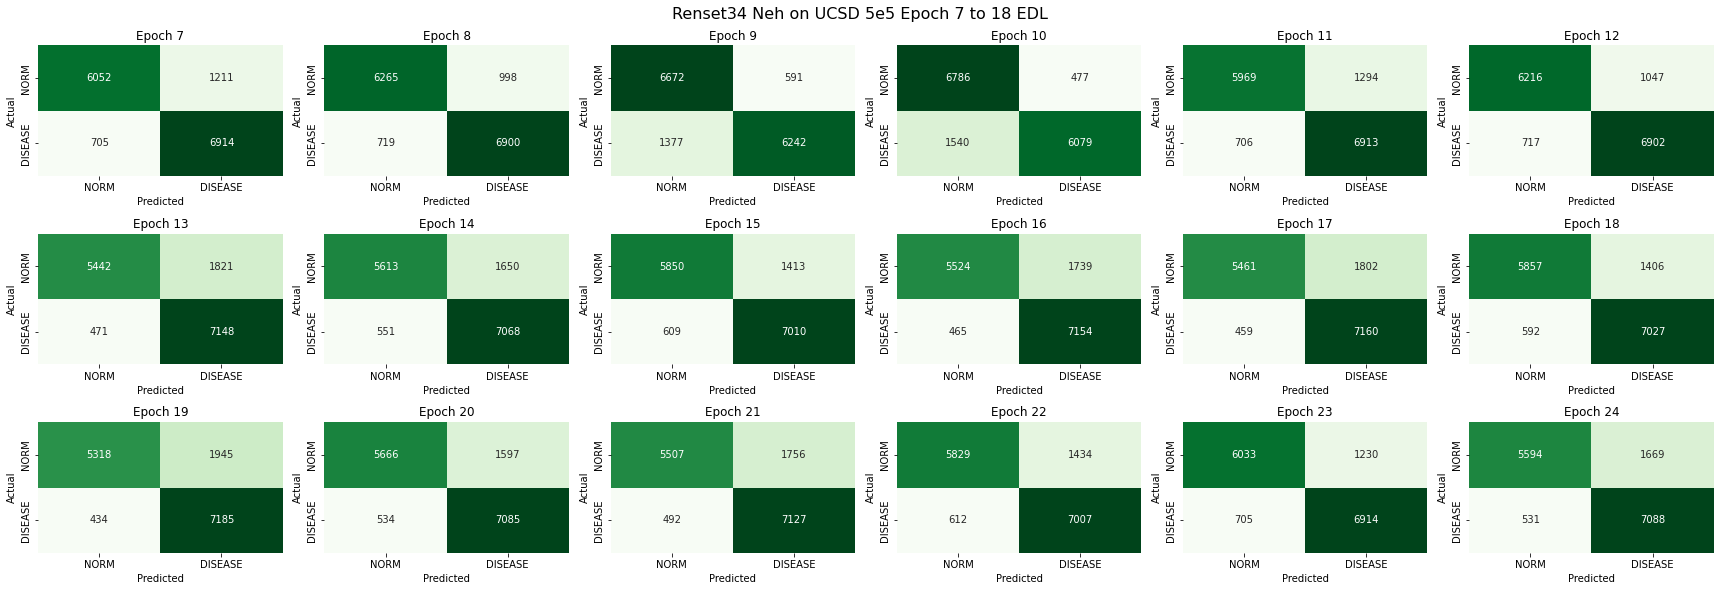


All inferences complete. Plot saved as 'multi_epoch_confusion_matrices.png'.


In [2]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score, 
                             precision_score, recall_score, classification_report, 
                             confusion_matrix)

# ===============================
# 1. Configuration & Paths
# ===============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BASE_CKPT_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_neh_binary_5e4_EDL/"
TEST_UCSD_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_split_test_15.csv"

IMG_SIZE = 512
NUM_CLASSES = 2
BATCH_SIZE = 32
EPOCHS_TO_TEST = range(7, 25)  # 12 to 22 inclusive

# ===============================
# 2. Model & Dataset Classes
# ===============================
class ResNet34_OCT(nn.Module):
    def __init__(self, num_classes=2, pretrained=True):
        super().__init__()

        # Load ResNet34 backbone
        # Note: In newer torchvision versions, weights=models.ResNet34_Weights.DEFAULT 
        # is preferred over pretrained=True
        self.backbone = models.resnet34(pretrained=pretrained)

        # Replace final fully connected layer
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

# Initialize and move to device
model = ResNet34_OCT(
    num_classes=NUM_CLASSES,
    pretrained=True
).to(DEVICE)

class UCSDOCTDataset(Dataset):
    def __init__(self, df, transform=None, label_col="binary_label"):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.label_col = label_col

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = row["new_file_path"]
        label = int(row[self.label_col])
        img = Image.open(img_path).convert("RGB")
        if self.transform is not None:
            img = self.transform(img)
        return img, label

# ===============================
# 3. Setup Data
# ===============================
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

df_ucsd = pd.read_csv(TEST_UCSD_CSV)
test_dataset = UCSDOCTDataset(df_ucsd, transform=test_transform, label_col="binary_label")
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

# To store results for plotting
all_cms = []
epoch_list = []


# ===============================
# 4. Inference Loop
# ===============================

for epoch in EPOCHS_TO_TEST:
    ckpt_path = os.path.join(BASE_CKPT_DIR, f"epoch_{epoch}.pth")
    if not os.path.exists(ckpt_path):
        print(f"Skipping: {ckpt_path} not found.")
        continue

    print(f"\nEvaluating Epoch {epoch}...")
    checkpoint = torch.load(ckpt_path, map_location=DEVICE)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.eval()

    epoch_preds = []
    epoch_labels = []

    with torch.no_grad():
        for images, labels in tqdm(test_loader, desc=f"Epoch {epoch}", leave=False):
            images = images.to(DEVICE)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            
            epoch_preds.extend(preds.cpu().numpy())
            epoch_labels.extend(labels.numpy())

    # Metrics
    macro_f1 = f1_score(epoch_labels, epoch_preds, average='macro')
    acc = accuracy_score(epoch_labels, epoch_preds)
    
    # Confusion Matrix Components
    cm = confusion_matrix(epoch_labels, epoch_preds)
    tn, fp, fn, tp = cm.ravel()
    npv = tn / (tn + fn + 1e-8)

    print(f"Epoch {epoch} | Macro F1: {macro_f1:.4f} | Acc: {acc:.4f} | NPV: {npv:.4f}")
    
    all_cms.append(cm)
    epoch_list.append(epoch)

# ===============================
# 5. Final Subplot Visualization
# ===============================
fig, axes = plt.subplots(3, 6, figsize=(24, 8)) # 2x6 to accommodate up to 11/12 epochs comfortably
axes = axes.flatten()

for i, (cm, ep) in enumerate(zip(all_cms, epoch_list)):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', ax=axes[i], cbar=False,
                xticklabels=["NORM", "DISEASE"], 
                yticklabels=["NORM", "DISEASE"])
    axes[i].set_title(f"Epoch {ep}")
    axes[i].set_ylabel('Actual')
    axes[i].set_xlabel('Predicted')

# Remove unused subplots
for j in range(len(all_cms), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.suptitle("Renset34 Neh on UCSD 5e5 Epoch 7 to 18 EDL", fontsize=16, y=1.02)
plt.savefig("confusionM_resnet34_NehOnUCSD_5e4_EDL.png")
plt.show()

print("\nAll inferences complete. Plot saved as 'multi_epoch_confusion_matrices.png'.")

/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



🔹 Evaluating Epoch 7


Epoch 07 | Acc: 0.5853 | F1: 0.4111 | AUC: 0.9066 | Prec: 0.7882 | Recall: 0.5238 | Spec: 0.0476 | NPV: 1.0000

🔹 Evaluating Epoch 8


Epoch 08 | Acc: 0.5648 | F1: 0.3616 | AUC: 0.8854 | Prec: 0.7824 | Recall: 0.5004 | Spec: 0.0007 | NPV: 1.0000

🔹 Evaluating Epoch 9


Epoch 09 | Acc: 0.5648 | F1: 0.3616 | AUC: 0.8401 | Prec: 0.7824 | Recall: 0.5004 | Spec: 0.0007 | NPV: 1.0000

🔹 Evaluating Epoch 10


...

Epoch 15 | Acc: 0.7146 | F1: 0.6561 | AUC: 0.9493 | Prec: 0.8292 | Recall: 0.6726 | Spec: 0.3468 | NPV: 0.9939

🔹 Evaluating Epoch 16


Epoch 16 | Acc: 0.7224 | F1: 0.6678 | AUC: 0.9402 | Prec: 0.8334 | Recall: 0.6814 | Spec: 0.3639 | NPV: 0.9961

🔹 Evaluating Epoch 17


Epoch 17 | Acc: 0.6218 | F1: 0.4912 | AUC: 0.8887 | Prec: 0.7968 | Recall: 0.5658 | Spec: 0.1322 | NPV: 0.9947

🔹 Evaluating Epoch 18


Epoch 18 | Acc: 0.6376 | F1: 0.5225 | AUC: 0.9072 | Prec: 0.8024 | Recall: 0.5839 | Spec: 0.1684 | NPV: 0.9958

🔹 Evaluating Epoch 19


Epoch 19 | Acc: 0.6744 | F1: 0.5899 | AUC: 0.9026 | Prec: 0.8158 | Recall: 0.6262 | Spec: 0.2530 | NPV: 0.9972


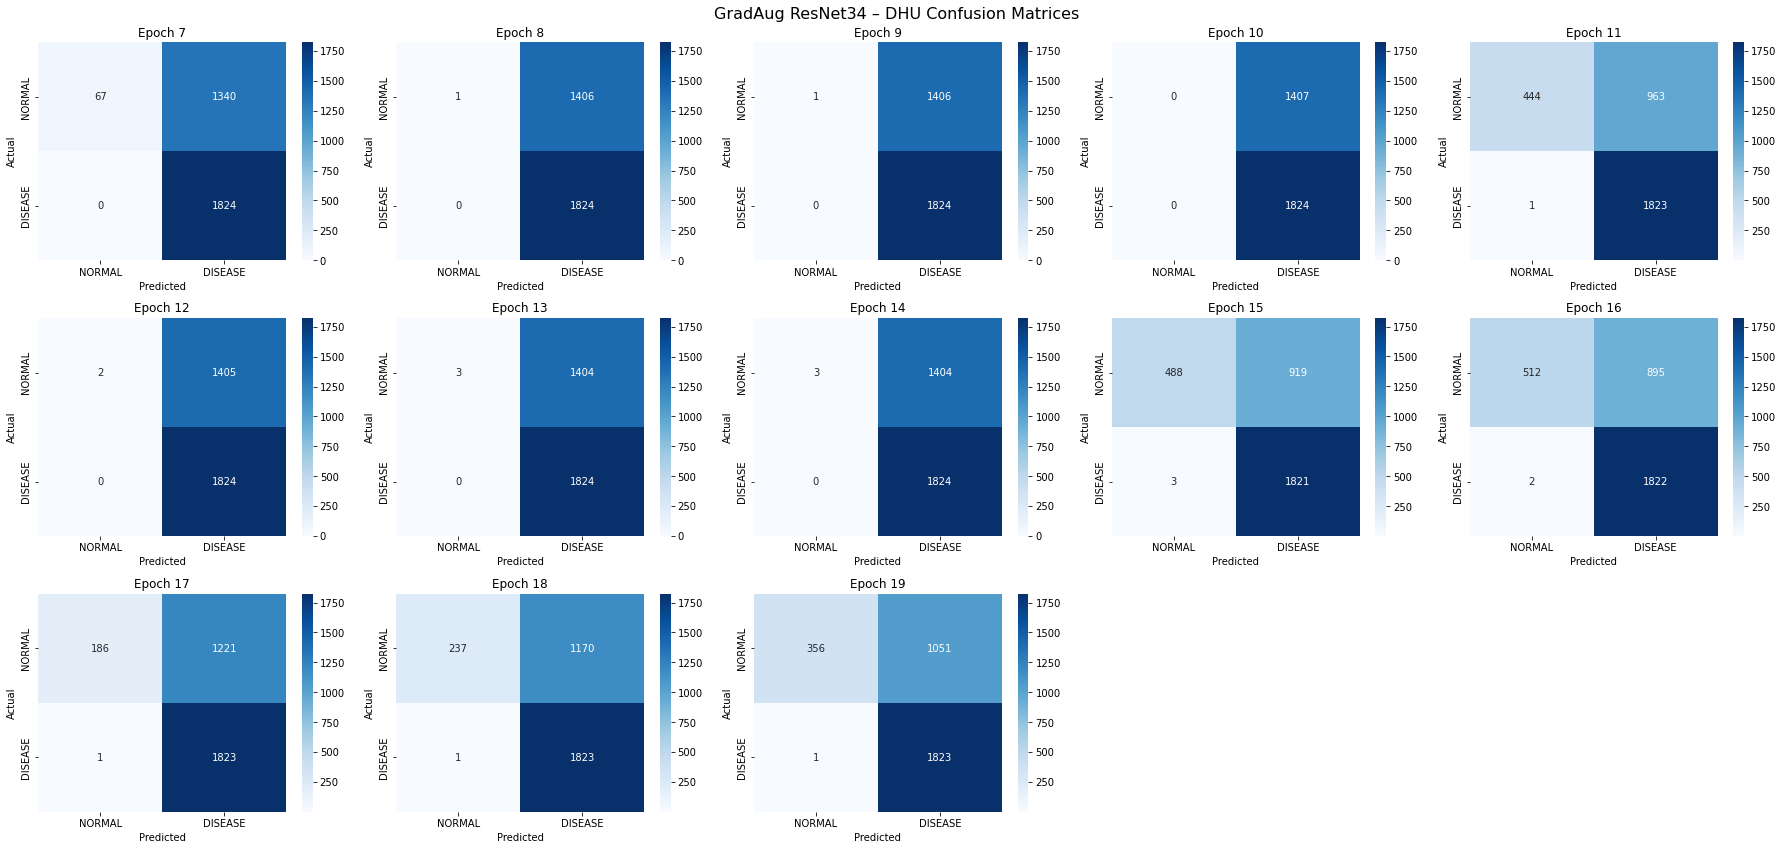


✅ DHU GradAug inference completed successfully.


In [5]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, confusion_matrix
)
from PIL import Image
from tqdm import tqdm

# ============================
# CONFIG
# ============================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 512
BATCH_SIZE = 32

BASE_CKPT_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_neh_binary_5e4_GradAug_EDL_NewLR"
DHU_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/dhu.csv"

EPOCHS_TO_TEST = range(7, 20)

# ============================
# MODEL
# ============================
class ResNet34GradAug(nn.Module):
    def __init__(self, num_classes=2, pretrained=False):
        super().__init__()
        base = models.resnet34(pretrained=pretrained)

        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool

        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4

        self.avgpool = base.avgpool
        self.fc = nn.Linear(512, num_classes)

    def forward_full(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


# ============================
# DATASET
# ============================
class DHUDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["new_file_path"]).convert("RGB")
        label = int(row["binary_label"])
        img = self.transform(img)
        return img, label


# ============================
# TRANSFORMS
# ============================
test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485, 0.456, 0.406],
        [0.229, 0.224, 0.225]
    )
])

# ============================
# LOAD DATA
# ============================
df = pd.read_csv(DHU_CSV)
dataset = DHUDataset(df, test_tf)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

# ============================
# MODEL INIT
# ============================
model = ResNet34GradAug(num_classes=2).to(DEVICE)

# ============================
# INFERENCE
# ============================
all_cms = []
epoch_list = []

for epoch in EPOCHS_TO_TEST:

    ckpt_path = f"{BASE_CKPT_DIR}/epoch_{epoch}.pth"
    if not os.path.exists(ckpt_path):
        print(f"Skipping epoch {epoch}")
        continue

    print(f"\n🔹 Evaluating Epoch {epoch}")

    ckpt = torch.load(ckpt_path, map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    all_probs, all_preds, all_targets = [], [], []

    with torch.no_grad():
        for imgs, labels in tqdm(loader, leave=False):
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model.forward_full(imgs)
            probs = torch.softmax(logits, dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            all_probs.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    # ============================
    # METRICS
    # ============================
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds, average="macro")
    prec = precision_score(all_targets, all_preds, average="macro")
    rec = recall_score(all_targets, all_preds, average="macro")
    auc = roc_auc_score(all_targets, all_probs)

    cm = confusion_matrix(all_targets, all_preds)
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp + 1e-8)
    npv = tn / (tn + fn + 1e-8)

    print(
        f"Epoch {epoch:02d} | "
        f"Acc: {acc:.4f} | "
        f"F1: {f1:.4f} | "
        f"AUC: {auc:.4f} | "
        f"Prec: {prec:.4f} | "
        f"Recall: {rec:.4f} | "
        f"Spec: {specificity:.4f} | "
        f"NPV: {npv:.4f}"
    )

    all_cms.append(cm)
    epoch_list.append(epoch)

# ============================
# PLOT CONFUSION MATRICES
# ============================
rows = 3
cols = int(np.ceil(len(all_cms) / rows))

fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 12))
axes = axes.flatten()

for i, (cm, ep) in enumerate(zip(all_cms, epoch_list)):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["NORMAL", "DISEASE"],
        yticklabels=["NORMAL", "DISEASE"],
        ax=axes[i]
    )
    axes[i].set_title(f"Epoch {ep}")
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")

for j in range(len(all_cms), len(axes)):
    fig.delaxes(axes[j])

plt.suptitle("GradAug ResNet34 – DHU Confusion Matrices", fontsize=16)
plt.tight_layout()
plt.savefig("GradAug_DHU_confusion_matrices.png", dpi=300)
plt.show()

print("\n✅ DHU GradAug inference completed successfully.")


In [3]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix
)
from PIL import Image
from tqdm import tqdm

# ============================
# CONFIG
# ============================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

IMG_SIZE = 512
BATCH_SIZE = 32
NUM_CLASSES = 2

# UCSD → NEH
CKPT_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_ucsd_binary_5e4_GradAug_EDL/epoch_17.pth"
NEH_TEST_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/neh_test.csv"

# ============================
# MODEL
# ============================
class ResNet34GradAug(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet34(weights=None)

        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool

        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4

        self.avgpool = base.avgpool
        self.fc = nn.Linear(512, num_classes)

    def forward_full(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


# ============================
# DATASET
# ============================
class NEHDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["new_file_path"]).convert("RGB")
        label = int(row["binary_label"])
        return self.transform(img), label


# ============================
# TRANSFORMS
# ============================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ============================
# LOAD DATA
# ============================
df = pd.read_csv(NEH_TEST_CSV)
dataset = NEHDataset(df, transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

# ============================
# LOAD MODEL
# ============================
model = ResNet34GradAug(num_classes=2).to(DEVICE)

ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# ============================
# INFERENCE
# ============================
all_probs = []
all_targets = []

with torch.no_grad():
    for imgs, labels in tqdm(loader, desc="UCSD → NEH Inference"):
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model.forward_full(imgs)
        probs = torch.softmax(logits, dim=1)

        all_probs.extend(probs[:, 1].cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_targets = np.array(all_targets)
preds = (all_probs > 0.5).astype(int)

# ============================
# METRICS
# ============================
acc = accuracy_score(all_targets, preds)
f1 = f1_score(all_targets, preds, average="macro")
precision = precision_score(all_targets, preds, average="macro")
recall = recall_score(all_targets, preds, average="macro")
auc = roc_auc_score(all_targets, all_probs)

tn, fp, fn, tp = confusion_matrix(all_targets, preds).ravel()
specificity = tn / (tn + fp + 1e-8)
npv = tn / (tn + fn + 1e-8)

# ============================
# RESULTS
# ============================
print("\n===== UCSD → NEH (Epoch 9) Results =====")
print(f"Accuracy     : {acc:.4f}")
print(f"Macro F1     : {f1:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"AUC          : {auc:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"NPV          : {npv:.4f}")


UCSD → NEH Inference: 100%|██████████| 31/31 [00:06<00:00,  4.87it/s]


===== UCSD → NEH (Epoch 9) Results =====
Accuracy     : 0.6991
Macro F1     : 0.4114
Precision    : 0.3495
Recall       : 0.5000
AUC          : 0.5000
Specificity  : 0.0000
NPV          : 0.0000



/home/bharath/.local/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [ ]:
import torch
import torch.nn as nn
import pandas as pd
import numpy as np
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from PIL import Image
from tqdm import tqdm
from sklearn.metrics import (f1_score, roc_auc_score, accuracy_score, 
                             precision_score, recall_score, confusion_matrix)

# ===============================
# 1. Configuration & Paths
# ===============================
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
CKPT_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_neh_binary_5e4/epoch_8.pth"
TEST_UCSD_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_split_test_15.csv"

IMG_SIZE = 512
NUM_CLASSES = 2
BATCH_SIZE = 32

# ===============================
# 2. Model & Dataset Classes
# ===============================
class ResNet34_OCT(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.backbone = models.resnet34(weights=None)
        in_features = self.backbone.fc.in_features
        self.backbone.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.backbone(x)

class UCSDOCTDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["new_file_path"]).convert("RGB")
        label = int(row["binary_label"])
        if self.transform:
            img = self.transform(img)
        return img, label

# ===============================
# 3. Setup & Loading
# ===============================
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

df_ucsd = pd.read_csv(TEST_UCSD_CSV)
test_loader = DataLoader(UCSDOCTDataset(df_ucsd, transform=test_transform), 
                         batch_size=BATCH_SIZE, shuffle=False, num_workers=4)

model = ResNet34_OCT(num_classes=NUM_CLASSES).to(DEVICE)

if os.path.exists(CKPT_PATH):
    print(f"Loading checkpoint: {CKPT_PATH}")
    checkpoint = torch.load(CKPT_PATH, map_location=DEVICE)
    state_dict = checkpoint['model_state_dict'] if 'model_state_dict' in checkpoint else checkpoint
    model.load_state_dict(state_dict)
    model.eval()
else:
    raise FileNotFoundError(f"Checkpoint not found at {CKPT_PATH}")

# ===============================
# 4. Inference
# ===============================
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for images, labels in tqdm(test_loader, desc="Inference"):
        images = images.to(DEVICE)
        outputs = model(images)
        
        probs = torch.softmax(outputs, dim=1)[:, 1]
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.numpy())

# ===============================
# 5. Metrics Calculation
# ===============================
# Confusion matrix for Specificity and NPV
cm = confusion_matrix(all_labels, all_preds)
tn, fp, fn, tp = cm.ravel()

acc = accuracy_score(all_labels, all_preds)
macro_f1 = f1_score(all_labels, all_preds, average='macro')
auc = roc_auc_score(all_labels, all_probs)
precision = precision_score(all_labels, all_preds, average='macro')
recall = recall_score(all_labels, all_preds, average='macro')
specificity = tn / (tn + fp + 1e-8)
npv = tn / (tn + fn + 1e-8)

print("\n" + "="*40)
print(f"STATUS: Inference Complete for Epoch 22")
print("="*40)
print(f"Accuracy:      {acc:.4f}")
print(f"Macro F1:      {macro_f1:.4f}")
print(f"AUC:           {auc:.4f}")
print(f"Precision:     {precision:.4f}")
print(f"Recall:        {recall:.4f}")
print(f"Specificity:   {specificity:.4f}")
print(f"NPV:           {npv:.4f}")
print("="*40)

Loading checkpoint: /mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_neh_binary_5e4/epoch_8.pth


Inference: 100%|██████████| 466/466 [01:06<00:00,  6.99it/s]


STATUS: Inference Complete for Epoch 22
Accuracy:      0.7841
Macro F1:      0.7767
AUC:           0.9121
Precision:     0.8167
Recall:        0.7802
Specificity:   0.6168
NPV:           0.9124


In [3]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import transforms
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, confusion_matrix
)
from PIL import Image
from tqdm import tqdm

class ResNet34GradAug(nn.Module):
    def __init__(self, num_classes=2, pretrained=False):
        super().__init__()
        base = models.resnet34(pretrained=pretrained)

        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool

        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4

        self.avgpool = base.avgpool
        self.fc = nn.Linear(512, num_classes)

    def forward_full(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)
    
class UCSDDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["new_file_path"]).convert("RGB")
        label = int(row["binary_label"])

        img = self.transform(img)
        return img, label

def edl_predict(logits):
    evidence = torch.nn.functional.softplus(logits)
    alpha = evidence + 1
    probs = alpha / alpha.sum(dim=1, keepdim=True)
    return probs, evidence

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 512
BATCH_SIZE = 32

BASE_CKPT_DIR = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_neh_binary_5e4_GradAug_EDL_NewLR"
TEST_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_split_test_15.csv"

EPOCHS_TO_TEST = range(7, 25)

test_tf = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

df = pd.read_csv(TEST_CSV)
test_ds = UCSDDataset(df, test_tf)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

model = ResNet34GradAug(num_classes=2, pretrained=False).to(DEVICE)

all_cms = []
epoch_list = []

for epoch in EPOCHS_TO_TEST:

    ckpt = torch.load(f"{BASE_CKPT_DIR}/epoch_{epoch}.pth", map_location=DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()

    all_probs, all_targets = [], []

    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc=f"Epoch {epoch}"):
            imgs = imgs.to(DEVICE)
            labels = labels.to(DEVICE)

            logits = model.forward_full(imgs)
            probs, _ = edl_predict(logits)

            all_probs.extend(probs[:, 1].cpu().numpy())
            all_targets.extend(labels.cpu().numpy())

    all_probs = np.array(all_probs)
    all_targets = np.array(all_targets)
    preds = (all_probs > 0.5).astype(int)

    acc = accuracy_score(all_targets, preds)
    f1 = f1_score(all_targets, preds)
    auc = roc_auc_score(all_targets, all_probs)

    cm = confusion_matrix(all_targets, preds)
    tn, fp, fn, tp = cm.ravel()
    npv = tn / (tn + fn + 1e-8)

    print(f"Epoch {epoch} | Acc={acc:.4f} | F1={f1:.4f} | AUC={auc:.4f} | NPV={npv:.4f}")

    all_cms.append(cm)
    epoch_list.append(epoch)

fig, axes = plt.subplots(3, 6, figsize=(24, 10))
axes = axes.flatten()

for i, (cm, ep) in enumerate(zip(all_cms, epoch_list)):
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Normal", "Disease"],
                yticklabels=["Normal", "Disease"],
                ax=axes[i])
    axes[i].set_title(f"Epoch {ep}")

for j in range(len(all_cms), len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("resnet34_EDL_GradAug_confusions_NEHOnUCSD.png")
plt.show()


/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Epoch 7: 100%|██████████| 466/466 [02:11<00:00,  3.54it/s]


Epoch 7 | Acc=0.6174 | F1=0.7216 | AUC=0.8206 | NPV=0.8832


Epoch 8: 100%|██████████| 466/466 [02:13<00:00,  3.48it/s]


Epoch 8 | Acc=0.5327 | F1=0.6851 | AUC=0.9280 | NPV=0.8723


Epoch 9: 100%|██████████| 466/466 [02:12<00:00,  3.52it/s]


...

Epoch 22 | Acc=0.6281 | F1=0.7294 | AUC=0.9316 | NPV=0.9215


Epoch 23: 100%|██████████| 466/466 [02:32<00:00,  3.05it/s]


Epoch 23 | Acc=0.6144 | F1=0.7225 | AUC=0.9298 | NPV=0.9187


Epoch 24:   2%|▏         | 8/466 [00:02<02:50,  2.68it/s]


KeyboardInterrupt: 

In [6]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd

from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    f1_score, roc_auc_score, accuracy_score,
    precision_score, recall_score, confusion_matrix
)
from PIL import Image
from tqdm import tqdm


# =========================
# Model
# =========================
class ResNet34GradAug(nn.Module):
    def __init__(self, num_classes=2, pretrained=False):
        super().__init__()
        base = models.resnet34(pretrained=pretrained)

        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool

        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4

        self.avgpool = base.avgpool
        self.fc = nn.Linear(512, num_classes)

    def forward_full(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


# =========================
# Dataset
# =========================
class UCSDDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["new_file_path"]).convert("RGB")
        label = int(row["binary_label"])
        return self.transform(img), label


# =========================
# EDL Prediction
# =========================
def edl_predict(logits):
    evidence = torch.nn.functional.softplus(logits)
    alpha = evidence + 1
    probs = alpha / alpha.sum(dim=1, keepdim=True)
    return probs


# =========================
# Config
# =========================
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
IMG_SIZE = 512
BATCH_SIZE = 32

CKPT_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_neh_binary_5e4_GradAug_EDL_NewLR/epoch_9.pth"
TEST_CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_split_test_15.csv"

# =========================
# Data
# =========================
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

df = pd.read_csv(TEST_CSV)
dataset = UCSDDataset(df, transform)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=False)

# =========================
# Load model
# =========================
model = ResNet34GradAug(num_classes=2).to(DEVICE)
ckpt = torch.load(CKPT_PATH, map_location=DEVICE)
model.load_state_dict(ckpt["model_state_dict"])
model.eval()

# =========================
# Inference
# =========================
all_probs = []
all_targets = []

with torch.no_grad():
    for imgs, labels in tqdm(loader, desc="Inference"):
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model.forward_full(imgs)
        probs = edl_predict(logits)

        all_probs.extend(probs[:, 1].cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_targets = np.array(all_targets)
preds = (all_probs > 0.5).astype(int)

# =========================
# Metrics
# =========================
acc = accuracy_score(all_targets, preds)
f1 = f1_score(all_targets, preds, average="macro")
auc = roc_auc_score(all_targets, all_probs)
precision = precision_score(all_targets, preds, average='macro')
recall = recall_score(all_targets, preds, average='macro')

# Extract confusion matrix components
tn, fp, fn, tp = confusion_matrix(all_targets, preds).ravel()

# Specificity = TN / (TN + FP)
# Measures how well the model identifies "NORMAL" cases
specificity = tn / (tn + fp + 1e-8)

# NPV = TN / (TN + FN)
# Measures confidence when the model predicts "NORMAL"
npv = tn / (tn + fn + 1e-8)

# =========================
# Results
# =========================
print("\n===== Epoch 9 Evaluation =====")
print(f"Accuracy     : {acc:.4f}")
print(f"Macro F1     : {f1:.4f}")
print(f"AUC          : {auc:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}") # Changed from Sensitivity
print(f"NPV          : {npv:.4f}")

/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
Inference: 100%|██████████| 466/466 [02:09<00:00,  3.61it/s]


===== Epoch 9 Evaluation =====
Accuracy     : 0.5388
Macro F1     : 0.4103
AUC          : 0.8905
Precision    : 0.6621
Recall       : 0.5280
Specificity  : 0.0738
NPV          : 0.7976


In [1]:
import torch
import numpy as np
import pandas as pd
from torchvision import transforms, models
from torch.utils.data import DataLoader, Dataset
from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    precision_score, recall_score, confusion_matrix
)
from PIL import Image
from tqdm import tqdm


# =========================
# Model
# =========================
class ResNet34GradAug(torch.nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        base = models.resnet34(pretrained=False)

        self.conv1 = base.conv1
        self.bn1 = base.bn1
        self.relu = base.relu
        self.maxpool = base.maxpool
        self.layer1 = base.layer1
        self.layer2 = base.layer2
        self.layer3 = base.layer3
        self.layer4 = base.layer4
        self.avgpool = base.avgpool
        self.fc = torch.nn.Linear(512, num_classes)

    def forward_full(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.fc(x)


# =========================
# Dataset
# =========================
class UCSDDataset(Dataset):
    def __init__(self, df, transform):
        self.df = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(row["new_file_path"]).convert("RGB")
        label = int(row["binary_label"])
        return self.transform(img), label


# =========================
# CONFIG
# =========================
DEVICE = "cuda"
CKPT = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/resnet34_neh_binary_5e4_GradAug_EDL_NewLR/epoch_9.pth"
CSV = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd_split_test_15.csv"

transform = transforms.Compose([
    transforms.Resize((512, 512)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])
])

# =========================
# Load
# =========================
df = pd.read_csv(CSV)
dataset = UCSDDataset(df, transform)
loader = DataLoader(dataset, batch_size=32, shuffle=False)

model = ResNet34GradAug().to(DEVICE)
model.load_state_dict(torch.load(CKPT)["model_state_dict"])
model.eval()

# =========================
# INFERENCE (CORRECT)
# =========================
all_probs, all_targets = [], []

with torch.no_grad():
    for imgs, labels in tqdm(loader):
        imgs = imgs.to(DEVICE)
        labels = labels.to(DEVICE)

        logits = model.forward_full(imgs)

        # ✅ Correct EDL inference
        evidence = torch.nn.functional.softplus(logits)
        alpha = evidence + 1
        probs = alpha / alpha.sum(dim=1, keepdim=True)

        all_probs.extend(probs[:, 1].cpu().numpy())
        all_targets.extend(labels.cpu().numpy())

all_probs = np.array(all_probs)
all_targets = np.array(all_targets)
preds = (all_probs > 0.5).astype(int)

# =========================
# Metrics
# =========================
acc = accuracy_score(all_targets, preds)
f1 = f1_score(all_targets, preds, average="macro")
precision = precision_score(all_targets, preds, average="macro")
recall = recall_score(all_targets, preds, average="macro")
auc = roc_auc_score(all_targets, all_probs)

tn, fp, fn, tp = confusion_matrix(all_targets, preds).ravel()
specificity = tn / (tn + fp + 1e-8)
npv = tn / (tn + fn + 1e-8)

print("\n===== FINAL RESULTS =====")
print(f"Accuracy     : {acc:.4f}")
print(f"Macro F1     : {f1:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"AUC          : {auc:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"NPV          : {npv:.4f}")


/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/bharath/.local/lib/python3.10/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)
100%|██████████| 466/466 [01:50<00:00,  4.23it/s]


===== FINAL RESULTS =====
Accuracy     : 0.5388
Macro F1     : 0.4103
Precision    : 0.6621
Recall       : 0.5280
AUC          : 0.8905
Specificity  : 0.0738
NPV          : 0.7976


In [1]:
import pandas as pd
from PIL import Image
from tqdm import tqdm
import os

# ===============================
# CONFIG
# ===============================
CSV_PATH = "/mnt/8b4bbd12-99b7-4ef1-9218-be56afd51a3d/UCSD/ucsd.csv"

# ===============================
# LOAD CSV
# ===============================
df = pd.read_csv(CSV_PATH)

print(f"Loaded {len(df)} rows")

# ===============================
# FUNCTION TO GET IMAGE SHAPE
# ===============================
def get_image_shape(path):
    try:
        with Image.open(path) as img:
            w, h = img.size
            return f"{w}x{h}"   # Height x Width
    except Exception as e:
        return "READ_ERROR"

# ===============================
# PROCESS IMAGES
# ===============================
tqdm.pandas(desc="Reading images")

df["image_shape"] = df["new_file_path"].progress_apply(get_image_shape)

# ===============================
# SAVE BACK TO SAME CSV
# ===============================
# df.to_csv(CSV_PATH, index=False)
print("✅ CSV updated successfully")

# ===============================
# STATS
# ===============================
shape_counts = df["image_shape"].value_counts()
shape_percent = (shape_counts / len(df)) * 100

print("\n🔹 Unique image shapes:", len(shape_counts))
print("\n🔹 Shape distribution:\n")

for shape, count in shape_counts.items():
    print(f"{shape:12s} : {count:6d} images ({shape_percent[shape]:.2f}%)")


Loaded 109309 rows


Reading images: 100%|██████████| 109309/109309 [18:50<00:00, 96.66it/s]  

✅ CSV updated successfully

🔹 Unique image shapes: 8

🔹 Shape distribution:

512x496      :  58037 images (53.09%)
768x496      :  29749 images (27.22%)
1536x496     :  11512 images (10.53%)
512x512      :   8659 images (7.92%)
1024x496     :   1329 images (1.22%)
384x496      :     21 images (0.02%)
900x455      :      1 images (0.00%)
642x277      :      1 images (0.00%)


In [1]:
import pandas as pd

df = pd.read_csv("ucsd_filtered.csv")
df['binary_label'].value_counts()

binary_label
1    50828
0    45617
Name: count, dtype: int64

In [2]:
import pandas as pd

df = pd.read_csv("dhu_filtered.csv")
df['binary_label'].value_counts()

binary_label
1    1458
0    1407
Name: count, dtype: int64